# **WSINDy with Experimental Data: Results**

This notebook illustrates the WSINDy being applied to experimental data from Heinrich et al. ([https://doi.org/10.48550/arXiv.2511.05486](https://doi.org/10.48550/arXiv.2511.05486)).
\
Identified PDE from that paper:
- in a **stationary** (i.e., laboratory) frame of reference: $$\begin{align*}
    u_t = w_{0}u_x + w_{1}(u^2)_x + w_{2}u_{xxx} + w_{3}u_{xxxxx}
\end{align*}$$

- in a **co-moving** frame of reference $\xi = x + w_0t$: $$\begin{align*}
    u_t = \tilde{w}_{1}(u^2)_{\xi} + \tilde{w}_{2}u_{\xi\xi\xi} + \tilde{w}_{3}u_{\xi\xi\xi\xi\xi}
\end{align*}$$

In [1]:
import sys, os

PROJECT_ROOT = os.getcwd()
while PROJECT_ROOT != os.path.dirname(PROJECT_ROOT) and not os.path.exists(
        os.path.join(PROJECT_ROOT, "wsindy_ode.py")):
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from netCDF4 import Dataset
from scipy.integrate import solve_ivp
from IPython.display import display,Math

from wsindy_ode import *
from compute_scattering_data import scattering_data, scattering_data_sequence
from recreate_results_helpers import *

import scipy.io as sio
from scipy import ndimage

torch.set_default_dtype(torch.float64)
#torch.manual_seed(0)

In [3]:
# Plot settings
import matplotlib

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

#### **IMPORT EXPERIMENTAL DATA**

Raw files:
- 18 training runs (`train_1.mat`, ... , `train_18.mat`)

- 7 test runs (`test_1.mat`, ... , `test_7.mat`)

In [4]:
# PHYSICAL CONSTANTS
H_DEPTH = 0.032 # Still-water depth h [meters]
G = 9.81 # Gravitational acceleration g [m/s^2]
FPS = 50 # Camera frame rate [frames/s]

DATA_DIR = os.path.join(PROJECT_ROOT, "experimental_data")
MAT_DIR = os.path.join(DATA_DIR, "Processed_mat")
NC_DIR = os.path.join(DATA_DIR, "netcdf")
os.makedirs(NC_DIR, exist_ok=True)

TRAIN_NAMES = [f"train_{k}" for k in range(1, 19)] # 18 training runs
TEST_NAMES  = [f"test_{k}"  for k in range(1, 8)] # 7 validation runs

# Nondimensional time step: t = t* sqrt(g/h), with t* = frame/FPS
DT_ND = (1.0/FPS) * np.sqrt(G/H_DEPTH)

In [5]:
# SOME HELPER FUNCTIONS

def load_x_grid():
    return sio.loadmat(os.path.join(MAT_DIR, "x_coordinates.mat"))["x_coordinates"].ravel()

def load_soliton_mat(name):
    return sio.loadmat(os.path.join(MAT_DIR, f"{name}.mat"))["y_coordinates"].astype(float)

# Repair edge-detection artifacts
def clean_spike_frames(U, amp_ratio=2.0, grow_factor=0.1):
    U = U.copy()
    p999 = np.percentile(U, 99.9)
    amp = U.max(axis=1)

    spike_frames = []
    for f in range(1, U.shape[0] - 1): # interior frames only
        if amp[f] <= amp_ratio * max(amp[f - 1], amp[f + 1], 1e-12):
            continue
        spike_frames.append(f)
        anom = U[f] - 0.5 * (U[f - 1] + U[f + 1])
        labels, _ = ndimage.label(anom > grow_factor * p999)
        bad = np.isin(labels, np.unique(labels[anom > 0.5 * amp[f]]))
        U[f, bad] = 0.5 * (U[f - 1, bad] + U[f + 1, bad])
    return U, np.array(spike_frames, dtype=int)

def subtract_baseline(U, pct=10.0):
    baseline = float(np.percentile(U, pct))
    return U - baseline, baseline

def nondimensionalize(x_m, eta_m):
    Nt = eta_m.shape[0]
    return x_m/H_DEPTH, np.arange(Nt)*DT_ND, eta_m/H_DEPTH

def save_soliton_netcdf(path, x, t, U, meta):
    with Dataset(path, "w") as nc:
        nc.createDimension("x", len(x))
        nc.createDimension("t", len(t))
        nc.createVariable("x", "f8", ("x",))[:] = x
        nc.createVariable("t", "f8", ("t",))[:] = t
        nc.createVariable("u", "f8", ("t", "x"))[:] = U
        for k, v in meta.items():
            setattr(nc, k, v)

# Nondim phase speed C = |dx*/dt*|/sqrt(gh) from tracking the main soliton crest
def phase_speed_nd(x, U):
    amp = U.max(axis=1)
    good = np.where(amp > 0.6 * amp.max())[0]
    crest = x[np.argmax(U, axis=1)]
    breaks = np.union1d(np.where(np.diff(crest[good]) > 0.8)[0], np.where(np.diff(good) > 1)[0])
    run = max(np.split(good, breaks + 1), key=len)
    span = x[-1] - x[0]
    run = run[(crest[run] > x[0] + 0.04 * span) & (crest[run] < x[-1] - 0.04 * span)]
    t_s = np.arange(U.shape[0]) / FPS # in seconds
    slope = np.polyfit(t_s[run], crest[run] * H_DEPTH, 1)[0]
    return abs(slope) / np.sqrt(G*H_DEPTH)

In [6]:
# IMPORT AND CLEAN DATA
x_m = load_x_grid()
soliton_data = {} # {x, t, U, meta-data}

for name in TRAIN_NAMES + TEST_NAMES:
    eta_raw = load_soliton_mat(name) # (Nt, Nx) [meters]
    eta_clean, fixed = clean_spike_frames(eta_raw)
    eta_bs, baseline = subtract_baseline(eta_clean)
    x, t, U = nondimensionalize(x_m, eta_bs)
    A = float(U.max())

    meta = dict(
        source_file = f"{name}.mat",
        split = "train" if name.startswith("train") else "test",
        h_depth_m = H_DEPTH,
        g = G,
        fps = FPS,
        dx_nd = float(x[1] - x[0]),
        dt_nd = float(DT_ND),
        amplitude_nd = A,
        kappa_est = float(np.sqrt(max(3*A/4, 0))),
        baseline_removed_mm = baseline,
        spike_frames_fixed = ",".join(map(str, fixed.tolist())) or "none",
        propagation = "-x (left-moving)",
        nondimensionalization = "x=x*/h, u=eta*/h, t=t* sqrt(g/h)")

    soliton_data[name] = dict(x=x, t=t, U=U, meta=meta)
    save_soliton_netcdf(os.path.join(NC_DIR, f"{name}.nc"), x, t, U, meta)

# Training versus test data
train_data = [(soliton_data[n]["x"], soliton_data[n]["t"], soliton_data[n]["U"]) for n in TRAIN_NAMES]
test_data = [(soliton_data[n]["x"], soliton_data[n]["t"], soliton_data[n]["U"]) for n in TEST_NAMES]
print(f"Extracted {len(soliton_data)} solitons -> {NC_DIR}/\n")

# Print a quick summary of the data
header = f"{'Run':9s}{'Nt':>5s}{'Amp.':>9s}{'Kappa':>9s}{'Depth (mm)':>14s}{'Bad frame IDs':>18s}"
print(header)
print("-" * len(header))
for name in TRAIN_NAMES + TEST_NAMES:
    metadata = soliton_data[name]["meta"]
    print(f"{name:10s}{soliton_data[name]['U'].shape[0]:5d}{metadata['amplitude_nd']:8.3f}"
          f"{metadata['kappa_est']:8.2f}{metadata['baseline_removed_mm'] * 1e3:14.3f}"
          f"{metadata['spike_frames_fixed']:>18s}")

Extracted 25 solitons -> /home/seth/projects/wsindy/scattering/experimental_data/netcdf/

Run         Nt     Amp.    Kappa    Depth (mm)     Bad frame IDs
----------------------------------------------------------------
train_1     151   0.543    0.64         0.036              none
train_2     151   0.547    0.64         0.084              none
train_3      99   0.534    0.63         0.094              none
train_4     151   0.447    0.58         0.089              none
train_5     151   0.413    0.56         0.132              none
train_6     151   0.251    0.43         0.129              none
train_7     151   0.212    0.40         0.127               108
train_8     151   0.302    0.48         0.098              none
train_9     151   0.443    0.58         0.077              none
train_10    151   0.602    0.67         0.094              none
train_11    151   0.511    0.62         0.084              none
train_12    151   0.308    0.48         0.045              none
train_13    

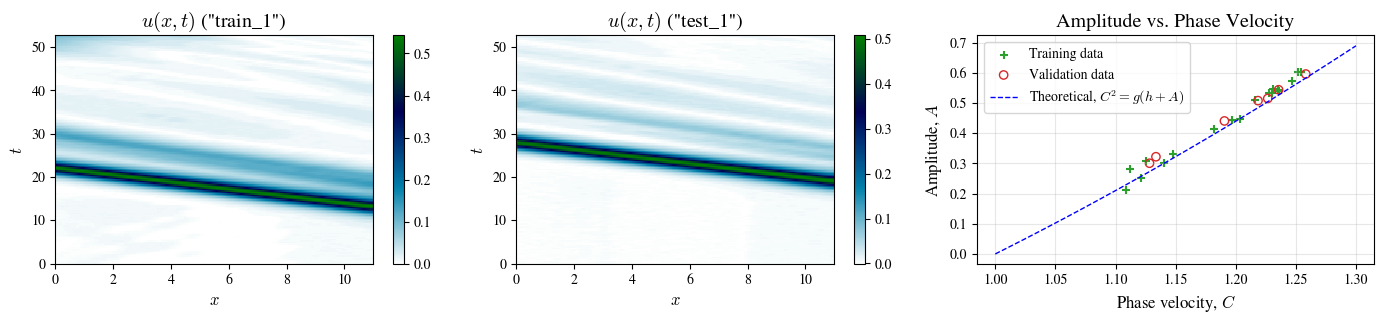

In [7]:
# PLOT THESE PUPS
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))

for ax, name in zip(axes[:2], ["train_1", "test_1"]):
    data = soliton_data[name]
    pc = ax.pcolormesh(data["x"], data["t"], data["U"], cmap="ocean_r")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$t$")
    ax.set_title(f"$u(x,t)$ (''{name}'')")
    fig.colorbar(pc, ax=ax)

# Cf. Figure 9 in the Heinrich et al. paper
A_train = [soliton_data[n]["U"].max() for n in TRAIN_NAMES]
C_train = [phase_speed_nd(soliton_data[n]["x"], soliton_data[n]["U"]) for n in TRAIN_NAMES]
A_test = [soliton_data[n]["U"].max() for n in TEST_NAMES]
C_test = [phase_speed_nd(soliton_data[n]["x"], soliton_data[n]["U"]) for n in TEST_NAMES]

ax = axes[2]
ax.scatter(C_train, A_train, marker="+", color="C2", label="Training data")
ax.scatter(C_test, A_test, marker="o", facecolor="none", edgecolor="C3", label="Validation data")
Cl = np.linspace(1.0, 1.3, 50)
ax.plot(Cl, Cl**2 - 1, "b--", lw=1, label=r"Theoretical, $C^2=g(h+A)$")
ax.set_xlabel("Phase velocity, $C$")
ax.set_ylabel("Amplitude, $A$")
ax.set_title(f"Amplitude vs. Phase Velocity")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **COMPUTE SCATTERING DATA**

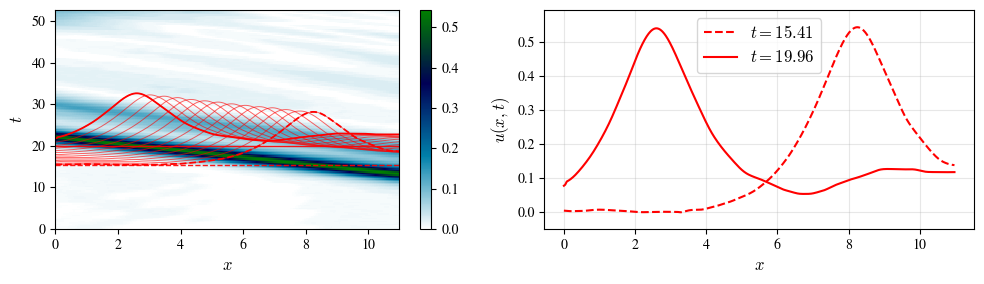

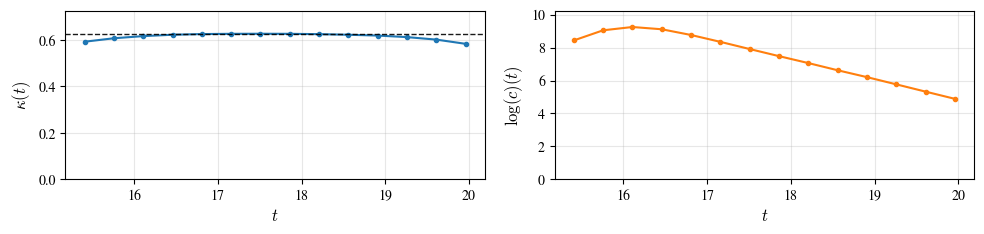

In [8]:
KDV_FACTOR = 1.5 # Characteristic scaling -> canonical KdV scaling
MIN_KAPPA = 0.15

# Example for illustration
name = "train_1"
#name = "train_8"
#name = "train_10"
#name = "train_16"

# Extract a specific run
data = soliton_data[name]
x,t,U = data["x"], data["t"], data["U"]
amp = U.max(axis=1)
xc = x[np.argmax(U, axis=1)]

# Frames where the soliton is completely inside the domain
margin = 1.5 / np.sqrt(np.maximum(KDV_FACTOR*amp/2.0, 1e-6))
#margin = 1.8 / np.sqrt(np.maximum(KDV_FACTOR*amp/2.0, 1e-6))
inframe = np.where((amp > 0.3*amp.max()) & (xc - x[0] >= margin) & (x[-1] - xc >= margin))[0]

# Plot this sucker
fig,ax = plt.subplots(1,2, figsize=(10,3))

pc = ax[0].pcolormesh(x,t,U, cmap="ocean_r")
scale = 2.8 * (t[inframe[-1]] - t[inframe[0]]) / U.max()
for f in inframe:
    ax[0].plot(x, t[f] + scale * U[f, :], color="red", lw=0.7, alpha=0.6)
ax[0].plot(x, t[inframe[0]] + scale * U[inframe[0], :], "r--", lw=1.3)
ax[0].plot(x, t[inframe[-1]] + scale * U[inframe[-1], :], "r-", lw=1.3)
ax[0].axhline(t[inframe[0]], ls="--", color="red", lw=1, alpha=0.9)
ax[0].axhline(t[inframe[-1]], ls="-", color="red", lw=1, alpha=0.9)
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$t$")
fig.colorbar(pc, ax=ax[0])

ax[1].plot(x, U[inframe[0],:], 'r--', label=f"$t={t[inframe[0]]:.2f}$")
ax[1].plot(x, U[inframe[-1],:], 'r-', label=f"$t={t[inframe[-1]]:.2f}$")
ax[1].set_xlabel("$x$")
ax[1].set_ylabel(r"$u(x,t)$")
ax[1].grid(alpha=0.3)
ax[1].set_ylim(U.min()-0.05, U.max()+0.05)
#ax[1].axis('equal')
ax[1].legend()
plt.tight_layout()
plt.show()

# Compute the scattering data for this run
seq = scattering_data_sequence(x, KDV_FACTOR * U, t_grid=t, snapshot_indices=inframe, min_kappa=MIN_KAPPA)
kappa = np.array([k.max() if len(k) else np.nan for k in seq.kappas])
logc  = np.array([lc[np.argmax(k)] if len(k) else np.nan
                  for k, lc in zip(seq.kappas, seq.log_cs)])

fig, ax = plt.subplots(1,2, figsize=(10,2.5))
ax[0].plot(seq.t, kappa, ".-")
#ax[0].plot(seq.t[1:], np.diff(kappa)/np.diff(seq.t), ".-")
ax[0].set_xlabel("$t$")
ax[0].set_ylabel(r"$\kappa(t)$")
ax[0].axhline(kappa.max(), ls="--", color="k", lw=1, alpha=0.9)
ax[0].set_ylim(0, kappa.max()+0.1)
ax[0].grid(alpha=0.3)

ax[1].plot(seq.t, logc, ".-", color="C1")
ax[1].set_xlabel("$t$")
ax[1].set_ylabel(r"$\log(c)(t)$")
#ax[1].plot(seq.t[1:], np.diff(logc)/np.diff(seq.t), ".-", color="C1")
ax[1].grid(alpha=0.3)
ax[1].set_ylim(0, logc.max()+1)
plt.tight_layout()
plt.show()

In [9]:
from helper_fcns import compute_residuals, symbolic_pde

WIN_L = 9 # frames per window

def experimental_scattering_series(name, L=WIN_L):
    data = soliton_data[name]
    x,t,U = data["x"], data["t"], data["U"]
    amp = U.max(1)
    xc = x[np.argmax(U, 1)]
    
    margin = 1.5 / np.sqrt(np.maximum(KDV_FACTOR * amp / 2.0, 1e-6))
    #margin = 1.8 / np.sqrt(np.maximum(KDV_FACTOR * amp / 2.0, 1e-6))
    inframe = np.where(amp > 0.1 * amp.max())[0]

    seq = scattering_data_sequence(x, KDV_FACTOR * U, t_grid=t, snapshot_indices=inframe, min_kappa=MIN_KAPPA)
    kappa = np.full(len(t), np.nan)
    logc = np.full(len(t), np.nan)

    for j,frame in enumerate(inframe):
        kappa_j, logc_j = seq.kappas[j], seq.log_cs[j]
        if len(kappa_j):
            i = int(np.argmax(kappa_j))
            kappa[frame] = kappa_j[i]
            logc[frame] = logc_j[i]

    valid = np.isfinite(kappa) & (xc - x[0] >= margin) & (x[-1] - xc >= margin)
    valid_inds = np.where(valid)[0]
    if len(valid_inds) == 0:
        return None
    run = max(np.split(valid_inds, np.where(np.diff(valid_inds) > 1)[0] + 1), key=len)
    if len(run) < L:
        return None
    window = run[len(run)//2 - L//2 : len(run)//2 - L//2 + L]

    return kappa[window], logc[window], window

In [10]:
# Compute (and cache) the scattering data for every run
cache = os.path.join(DATA_DIR, "exp_scattering_states_strict.pt")
if os.path.exists(cache):
    blob = torch.load(cache, weights_only=False)
    STATES, WINS = blob["STATES"], blob["WINS"]
else:
    STATES, WINS = {}, {}
    for name in TRAIN_NAMES + TEST_NAMES:
        res = experimental_scattering_series(name)
        if res is not None:
            STATES[name] = (res[0], res[1]); WINS[name] = res[2]
    torch.save({"STATES": STATES, "WINS": WINS}, cache)

# Shared window time grid and the stacked training states [kappa, log c]
t_scat = torch.tensor(np.arange(WIN_L) * DT_ND)
stacked_states = [[torch.tensor(STATES[n][0]), torch.tensor(STATES[n][1])]
                  for n in TRAIN_NAMES if n in STATES]

# Super-sample in time
from scipy.interpolate import CubicSpline

# N_SS, M_SS, P_SS = 81, 15, 7
N_SS, M_SS, P_SS = 81, 20, 10
t_fit = torch.tensor(np.linspace(0, (WIN_L - 1) * DT_ND, N_SS))
stacked_ss = [[torch.tensor(CubicSpline(t_scat.numpy(), s[0].numpy())(t_fit.numpy())),
               torch.tensor(CubicSpline(t_scat.numpy(), s[1].numpy())(t_fit.numpy()))]
              for s in stacked_states]

n_tr = sum(n in STATES for n in TRAIN_NAMES)
n_te = sum(n in STATES for n in TEST_NAMES)
kmin = min(s[0].min() for s in stacked_states)
kmax = max(s[0].max() for s in stacked_states)

print(f"scattering series: {n_tr}/18 train, {n_te}/7 test solitons;"
      f"window L={WIN_L}, dt={DT_ND:.3f}, t in [0, {t_scat[-1]:.2f}]; super-sampled to N={N_SS}")
print(f"kappa over training stack: [{kmin:.3f}, {kmax:.3f}]")

scattering series: 18/18 train, 7/7 test solitons;window L=9, dt=0.350, t in [0, 2.80]; super-sampled to N=81
kappa over training stack: [0.370, 0.654]


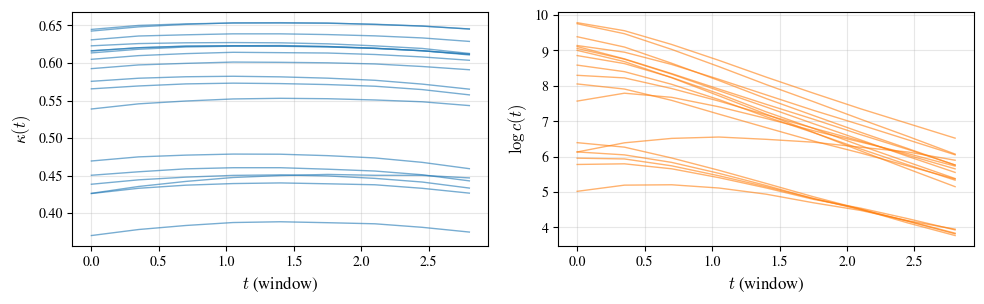

In [11]:
# Stacked training trajectories
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))

for n in TRAIN_NAMES:
    if n not in STATES:
        continue
    kap, lc = STATES[n]
    ax[0].plot(t_scat, kap, "-", color="C0", lw=1, alpha=0.6)
    ax[1].plot(t_scat, lc, "-", color="C1", lw=1, alpha=0.6)

ax[0].set_xlabel("$t$ (window)")
ax[0].set_ylabel(r"$\kappa(t)$")
ax[0].grid(alpha=0.3)

ax[1].set_xlabel("$t$ (window)")
ax[1].set_ylabel(r"$\log c(t)$")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **RUN WSINDY**

In [12]:
from helper_fcns import compute_residuals, symbolic_pde

# Run WSINDy
names = [r'\kappa', r'\log(c)']
# beta_kappa = [[1,0], [2,0], [3,0]] # k, k^2, k^3
# beta_logc  = [[0,1], [0,2], [0,3]] # k, k^2, k^3
beta_kappa = [[0,0], [1,0], [2,0], [3,0]]#, [4,0], [5,0]]
beta_logc  = [[0,0], [0,1], [0,3], [1,0], [2,0], [3,0]] # good w/ Lambda=1e-1
#beta_logc  = [[0,0], [0,1], [0,2], [0,3]]

# Fit each equation on the super-sampled data
hyperparams = {'m':[20], 'p':[10], 's':[1], 'rescale':False, 'trigger_BIC':'poor_fit'} # good w/ Lambda=1e-4 thru 1e-1

m_k, _, w_kappa = fit_wsindy_bic_stacked_eq(stacked_ss, t_fit, names, beta_kappa, eq=0, **hyperparams)
m_l, _, w_logc  = fit_wsindy_bic_stacked_eq(stacked_ss, t_fit, names, beta_logc, eq=1, **hyperparams, Lambda=1e-1)

models = [m_k, m_l]
coeffs = [w_kappa, w_logc]
beta = [beta_kappa, beta_logc]

100%|██████████| 1/1 [00:00<00:00, 930.83it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 738
Num. terms = 4
cond(G) = 5.402e+03

RESULTS
ODE: \kappa_{t} = 
Nonzero terms = 0
Rel. L2 error = 1.000
R^2 = -0.026
Lambda = 4.095e-02
Loss = 0.894
gamma^2 = 12.365
BIC triggered = True
BIC Delta = 2.003


<IPython.core.display.Math object>

100%|██████████| 1/1 [00:00<00:00, 711.62it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 738
Num. terms = 6
cond(G) = 8.046e+04

RESULTS
ODE: \log(c)_{t} = - 3.46(\kappa) - 2.60(\kappa^3) + 0.20(\log(c))
Nonzero terms = 3
Rel. L2 error = 0.134
R^2 = 0.803
Lambda = 1.000e-01
Loss = 0.571
gamma^2 = 12.365
BIC triggered = False
BIC Delta = n/a (not triggered)


<IPython.core.display.Math object>

#### **VALIDATION**

IST reconstruction on held-out data

soliton    forecast RMSE   floor RMSE  forecast/peak
----------------------------------------------------
test_1             0.059        0.044            8%
test_2             0.065        0.053            8%
test_3             0.098        0.102           12%
test_4             0.128        0.167           27%
test_5             0.108        0.139           25%
test_6             0.164        0.223           18%
test_7             0.155        0.227           24%


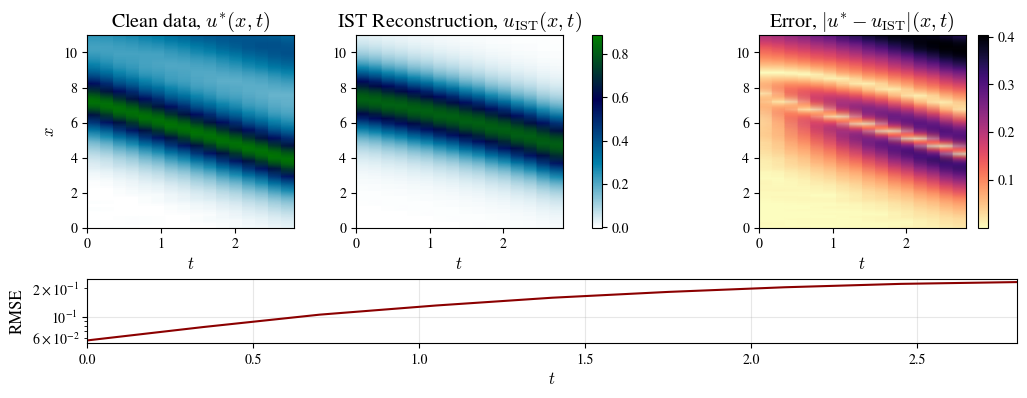

In [13]:
from compute_scattering_data import IST_reflectionless

t_win = np.arange(WIN_L) * DT_ND
print(f"{'soliton':9s}{'forecast RMSE':>15s}{'floor RMSE':>13s}{'forecast/peak':>15s}")
print('-' * 52)

for n in TEST_NAMES:
    if n not in STATES:
        continue
    kap, lc = STATES[n]
    win = WINS[n]
    x = soliton_data[n]['x']
    U_star = KDV_FACTOR * soliton_data[n]['U'][win]
    states = [torch.tensor(kap), torch.tensor(lc)]
    fc_rmse, _, _ = RMSE_of_forecast(states, U_star, x, t_win, coeffs, beta, plot=False)
    U_floor = np.array([IST_reflectionless(x, [kap[j]], [np.exp(lc[j])]) for j in range(WIN_L)])
    fl_rmse = np.sqrt(np.mean((U_star - U_floor) ** 2))
    print(f"{n:9s}{fc_rmse:15.3f}{fl_rmse:13.3f}{fc_rmse / U_star.max():>14.0%}")

# Visualize one reconstruction (forecast vs data)
name = "test_6"
kap, lc = STATES[name]
win = WINS[name]
x = soliton_data[name]['x']
U_star = KDV_FACTOR * soliton_data[name]['U'][win]
_ = RMSE_of_forecast([torch.tensor(kap), torch.tensor(lc)], U_star, x, t_win, coeffs, beta, plot=True)

#### **IDENTIFIABILITY (PDE vs ODE)**

In [231]:
from wsindy_pde import WSINDy as WSINDy_PDE
from helper_fcns import symbolic_pde

# Pick a few datasets
IDENT_NAMES = ['train_1']

alpha_pde = [[0,1], [0,0],[1,0],[2,0],[3,0],[4,0],[5,0]] # LHS=d/dt, then d/dx^0...d/dx^5
beta_pde  = [[1], [2]] # u, u^2

# Run WSINDy for PDEs
libs, lhss, container, rhs_names = [], [], None, None
for name in IDENT_NAMES:
    d = soliton_data[name]
    U_pde = torch.tensor(d["U"].T.copy())
    X_pde = [torch.tensor(d["x"].copy()), torch.tensor(d["t"].copy())]
    #model = WSINDy_PDE(U_pde, alpha_pde, beta_pde, X_pde, verbosity=False, rescale=True, s=[1,1]) # discovers nonlinearity
    model = WSINDy_PDE(U_pde, alpha_pde, beta_pde, X_pde, verbosity=False, rescale=False, s=[1,1]) # discovers linear eqn
    G, powers, derivs, rhs = model.create_default_library()
    model.build_lhs('u' + model.derivative_names[0])
    model.set_library(G, powers, derivs, rhs)
    libs.append(model.library); lhss.append(model.lhs)
    if container is None:
        container, rhs_names = model, rhs
        
container.library = torch.cat(libs, dim=0)
container.lhs = torch.cat(lhss, dim=0)
container.MSTLS()

container.print_report()
display(Math(symbolic_pde(container.lhs_name, rhs_names, container.coeffs)))

100%|██████████| 6/6 [00:00<00:00, 66.76it/s]


HYPER-PARAMETERS
m = [35, 19]
p = [9, 11]
s = [1, 1]
Not rescaled.

LIBRARY
Num. query points = 127690
Num. terms = 12
cond(G) = 1.076e+04

RESULTS
PDE: u_{t} = + 1.21(u)_{x}
Nonzero terms = 1
Rel. L2 error = 0.115
R^2 = 0.987
Lambda = 3.237e-01
Loss = 0.177


<IPython.core.display.Math object>

In [239]:
# In scattering coords
IDENT_NAMES = ['train_1']
#IDENT_NAMES = ['train_6']

train_in_states = [n for n in TRAIN_NAMES if n in STATES]
ident_ss = [stacked_ss[train_in_states.index(n)] for n in IDENT_NAMES]
print(f"Scattering ODE fit over {len(ident_ss)} datasets: {IDENT_NAMES}\n")

names = [r'\kappa', r'\log(c)']
#beta_logc  = [[0,1], [0,2], [0,3]]
beta_logc  = [[0,1], [0,2], [0,3]]
hyperparams = {'m':[19], 'p':[11], 's':[1], 'rescale':False, 'trigger_BIC':'poor_fit'}
#hyperparams = {'m':[19], 'p':[11], 's':[1], 'rescale':True, 'trigger_BIC':'poor_fit'}

_,_,_ = fit_wsindy_bic_stacked_eq(ident_ss, t_fit, names, beta_logc, eq=1, **hyperparams)

Scattering ODE fit over 1 datasets: ['train_1']



100%|██████████| 1/1 [00:00<00:00, 484.67it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [19]
p = [11]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 43
Num. terms = 3
cond(G) = 1.331e+06

RESULTS
ODE: \log(c)_{t} = - 1.96(\kappa)
Nonzero terms = 1
Rel. L2 error = 0.011
R^2 = -0.019
Lambda = 3.728e-04
Loss = 0.336
gamma^2 = 0.727
BIC triggered = False
BIC Delta = n/a (not triggered)


<IPython.core.display.Math object>